In [155]:
import pandas as pd   

train=pd.read_csv("/Users/withmocha/Desktop/DATA/SW DACON(24)/Data/main/train/train data0704(300).csv",index_col=0)

train

,0,1,2,3,4,5,6,7,8,9,...,291,292,293,294,295,296,297,298,299,label
0,-394.936279,-342.587677,-357.504242,-389.995789,-371.906921,-337.934479,-373.743652,-372.747040,-400.585815,-500.081055,...,-15.619810,-17.812935,-15.604845,-15.523780,-6.727620,-0.076917,-5.515199,-11.362299,-6.199681,real
1,-581.788025,-493.333282,-410.954376,-401.585815,-452.935852,-559.960815,-639.186523,-577.563904,-549.041748,-571.204224,...,-14.141809,-13.576027,0.213736,6.639369,6.110199,9.394777,13.347346,2.007246,4.924625,fake
2,-517.554138,-425.886932,-376.557495,-396.908142,-454.959808,-460.856201,-462.123627,-454.131134,-449.885803,-389.053894,...,-5.227354,8.152917,2.191056,-5.814029,-9.699948,-1.383227,16.272785,32.905407,26.145744,real
3,-394.363861,-368.538696,-439.574280,-514.239624,-506.364410,-452.762970,-411.703979,-411.203644,-458.048096,-529.425110,...,-13.779792,-34.914589,-22.075352,-4.288475,-0.907035,3.008495,8.213977,-13.879394,-22.756290,real
4,-450.617249,-434.187286,-460.728149,-434.470032,-380.399719,-363.353516,-364.176392,-368.033844,-358.251556,-349.455658,...,-19.675175,-19.487978,-0.979615,16.651348,19.386683,6.234925,-11.419584,-18.520580,-14.338546,real
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55433,-579.553955,-504.509705,-438.041626,-435.807068,-432.775116,-430.017151,-447.504150,-494.811523,-482.655396,-455.870026,...,-7.600307,-2.779206,-3.708735,-12.006880,-41.652866,-49.543015,-37.759064,-11.756623,-5.663359,real
55434,-511.036774,-456.407471,-439.349365,-490.263489,-543.329224,-540.333984,-562.810791,-515.110779,-492.389801,-524.895813,...,-3.814789,-3.736182,-8.379069,-13.680686,-14.760188,-0.919719,10.037119,3.631087,-12.900438,fake
55435,-223.470337,-255.177841,-401.685364,-517.920410,-651.353577,-442.551727,-376.734009,-347.039093,-342.265808,-358.595612,...,-35.967285,-26.440685,-4.818725,5.805700,-4.125793,-5.293243,-6.844064,-9.730085,-6.355603,fake
55436,-613.153320,-546.741638,-530.802673,-541.177429,-515.064331,-449.687378,-443.373383,-485.865997,-513.414490,-477.019653,...,-61.294006,-55.863243,-61.458111,-67.574844,-58.098213,-25.274656,17.015158,13.512698,2.304325,fake


In [156]:
train.isnull().sum()

0        0
1        0
2        0
3        0
4        0
        ..
296      0
297      0
298      0
299      0
label    0
Length: 301, dtype: int64

In [157]:
train.iloc[0,train.shape[1]-1]

'real'

In [158]:
train.shape

(55438, 301)

In [159]:
train_y=pd.DataFrame(index=range(train.shape[0]),columns=['label'])

In [160]:
for i in range(train.shape[0]):     
    if train.iloc[i,train.shape[1]-1]=='real':
        train_y.iloc[i,0]=1.0
    elif train.iloc[i,train.shape[1]-1]=='fake':
        train_y.iloc[i,0]=0.0

In [161]:
train_y

,label
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
55433,1.0
55434,0.0
55435,0.0
55436,0.0


In [162]:
train_y.isnull().sum()

label    0
dtype: int64

In [163]:
train_x=train.drop(columns=['label'])

In [164]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

train_x=pd.DataFrame(scaler.fit_transform(train_x))
train_x

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,1.577139,1.685618,1.509007,1.295827,1.678989,2.105967,1.657054,1.654984,1.343854,0.202374,...,-0.562711,-0.083612,-0.166318,-0.087201,-0.083032,0.247552,0.502819,0.293324,0.067564,0.258854
1,-0.752822,-0.114233,0.863592,1.152174,0.698434,-0.496983,-1.407961,-0.720971,-0.391509,-0.625530,...,0.206934,-0.027461,-0.005709,0.511231,0.759128,0.735769,0.864204,1.012587,0.578770,0.685882
2,0.048147,0.691053,1.278937,1.210152,0.673941,0.664881,0.636548,0.710897,0.767566,1.494778,...,-0.040316,0.311210,0.817970,0.586035,0.285921,0.134516,0.452978,1.124140,1.760212,1.500498
3,1.584276,1.375772,0.518004,-0.244115,0.051878,0.759762,1.218733,1.208872,0.672153,-0.139204,...,0.669201,-0.013707,-0.814590,-0.331987,0.343889,0.468906,0.620541,0.816842,-0.028682,-0.376705
4,0.882821,0.591950,0.262569,0.744590,1.576215,1.807964,1.767525,1.709658,1.838717,1.955718,...,0.438287,-0.237680,-0.229813,0.466086,1.139565,1.240668,0.743642,0.068179,-0.206145,-0.053573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55433,-0.724964,-0.247676,0.536511,0.728018,0.942405,1.026426,0.805356,0.238989,0.384509,0.717009,...,-0.307028,0.221059,0.403566,0.362840,0.050604,-1.080640,-1.384518,-0.936194,0.052486,0.279441
55434,0.129415,0.326648,0.520720,0.053057,-0.395444,-0.266886,-0.526066,0.003509,0.270719,-0.086481,...,0.126159,0.364875,0.367290,0.186157,-0.012998,-0.057923,0.470663,0.886362,0.640860,0.001632
55435,3.715245,2.729262,0.975516,-0.289737,-1.702680,0.879475,1.622525,1.953206,2.025581,1.849325,...,-0.492566,-0.856636,-0.493370,0.320848,0.727450,0.346499,0.303795,0.242652,0.129974,0.252868
55436,-1.143934,-0.751911,-0.583587,-0.577996,-0.053402,0.795819,0.853053,0.342760,0.024953,0.470818,...,-1.277754,-1.818827,-1.608690,-1.821876,-2.060880,-1.706049,-0.458579,1.152448,1.018700,0.585297


In [165]:
train_x

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,1.577139,1.685618,1.509007,1.295827,1.678989,2.105967,1.657054,1.654984,1.343854,0.202374,...,-0.562711,-0.083612,-0.166318,-0.087201,-0.083032,0.247552,0.502819,0.293324,0.067564,0.258854
1,-0.752822,-0.114233,0.863592,1.152174,0.698434,-0.496983,-1.407961,-0.720971,-0.391509,-0.625530,...,0.206934,-0.027461,-0.005709,0.511231,0.759128,0.735769,0.864204,1.012587,0.578770,0.685882
2,0.048147,0.691053,1.278937,1.210152,0.673941,0.664881,0.636548,0.710897,0.767566,1.494778,...,-0.040316,0.311210,0.817970,0.586035,0.285921,0.134516,0.452978,1.124140,1.760212,1.500498
3,1.584276,1.375772,0.518004,-0.244115,0.051878,0.759762,1.218733,1.208872,0.672153,-0.139204,...,0.669201,-0.013707,-0.814590,-0.331987,0.343889,0.468906,0.620541,0.816842,-0.028682,-0.376705
4,0.882821,0.591950,0.262569,0.744590,1.576215,1.807964,1.767525,1.709658,1.838717,1.955718,...,0.438287,-0.237680,-0.229813,0.466086,1.139565,1.240668,0.743642,0.068179,-0.206145,-0.053573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55433,-0.724964,-0.247676,0.536511,0.728018,0.942405,1.026426,0.805356,0.238989,0.384509,0.717009,...,-0.307028,0.221059,0.403566,0.362840,0.050604,-1.080640,-1.384518,-0.936194,0.052486,0.279441
55434,0.129415,0.326648,0.520720,0.053057,-0.395444,-0.266886,-0.526066,0.003509,0.270719,-0.086481,...,0.126159,0.364875,0.367290,0.186157,-0.012998,-0.057923,0.470663,0.886362,0.640860,0.001632
55435,3.715245,2.729262,0.975516,-0.289737,-1.702680,0.879475,1.622525,1.953206,2.025581,1.849325,...,-0.492566,-0.856636,-0.493370,0.320848,0.727450,0.346499,0.303795,0.242652,0.129974,0.252868
55436,-1.143934,-0.751911,-0.583587,-0.577996,-0.053402,0.795819,0.853053,0.342760,0.024953,0.470818,...,-1.277754,-1.818827,-1.608690,-1.821876,-2.060880,-1.706049,-0.458579,1.152448,1.018700,0.585297


In [166]:
from sklearn.feature_selection import VarianceThreshold

# 분산이 낮은 특성 제거
selector = VarianceThreshold(threshold=0.1)
train_x = pd.DataFrame(selector.fit_transform(train_x))
train_x

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,1.577139,1.685618,1.509007,1.295827,1.678989,2.105967,1.657054,1.654984,1.343854,0.202374,...,-0.562711,-0.083612,-0.166318,-0.087201,-0.083032,0.247552,0.502819,0.293324,0.067564,0.258854
1,-0.752822,-0.114233,0.863592,1.152174,0.698434,-0.496983,-1.407961,-0.720971,-0.391509,-0.625530,...,0.206934,-0.027461,-0.005709,0.511231,0.759128,0.735769,0.864204,1.012587,0.578770,0.685882
2,0.048147,0.691053,1.278937,1.210152,0.673941,0.664881,0.636548,0.710897,0.767566,1.494778,...,-0.040316,0.311210,0.817970,0.586035,0.285921,0.134516,0.452978,1.124140,1.760212,1.500498
3,1.584276,1.375772,0.518004,-0.244115,0.051878,0.759762,1.218733,1.208872,0.672153,-0.139204,...,0.669201,-0.013707,-0.814590,-0.331987,0.343889,0.468906,0.620541,0.816842,-0.028682,-0.376705
4,0.882821,0.591950,0.262569,0.744590,1.576215,1.807964,1.767525,1.709658,1.838717,1.955718,...,0.438287,-0.237680,-0.229813,0.466086,1.139565,1.240668,0.743642,0.068179,-0.206145,-0.053573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55433,-0.724964,-0.247676,0.536511,0.728018,0.942405,1.026426,0.805356,0.238989,0.384509,0.717009,...,-0.307028,0.221059,0.403566,0.362840,0.050604,-1.080640,-1.384518,-0.936194,0.052486,0.279441
55434,0.129415,0.326648,0.520720,0.053057,-0.395444,-0.266886,-0.526066,0.003509,0.270719,-0.086481,...,0.126159,0.364875,0.367290,0.186157,-0.012998,-0.057923,0.470663,0.886362,0.640860,0.001632
55435,3.715245,2.729262,0.975516,-0.289737,-1.702680,0.879475,1.622525,1.953206,2.025581,1.849325,...,-0.492566,-0.856636,-0.493370,0.320848,0.727450,0.346499,0.303795,0.242652,0.129974,0.252868
55436,-1.143934,-0.751911,-0.583587,-0.577996,-0.053402,0.795819,0.853053,0.342760,0.024953,0.470818,...,-1.277754,-1.818827,-1.608690,-1.821876,-2.060880,-1.706049,-0.458579,1.152448,1.018700,0.585297


In [167]:
from sklearn.decomposition import PCA

# 주성분 분석을 통한 차원 축소
pca = PCA(n_components=200)  
train_x = pd.DataFrame(pca.fit_transform(train_x))

In [168]:
train_x

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-5.514793,4.898899,-1.440184,-0.632690,4.674605,3.904384,-1.993009,0.597378,-2.856765,0.417784,...,-0.233432,-0.514539,-0.031444,0.102905,-0.070406,-0.073675,-0.010177,0.035535,-0.009301,0.007253
1,-10.870789,-0.590519,3.288119,2.367130,-1.683714,-2.728439,2.985457,0.298132,1.886323,-0.603307,...,-0.313224,-0.133602,0.057733,-0.157311,-0.049917,-0.065330,0.039576,-0.212058,-0.015131,0.067086
2,5.764756,5.467100,1.497226,3.363941,1.143439,0.976595,2.737553,-1.875593,0.236673,-1.457828,...,-0.104072,0.326163,-0.118458,-0.300637,0.317984,-0.055638,0.170745,-0.031975,0.073824,0.042698
3,3.684493,-1.394877,2.635171,-1.056024,1.474233,3.978592,1.798231,1.204134,1.751593,-1.420894,...,-0.209551,-0.015729,0.033310,-0.146679,0.128190,-0.221989,-0.114693,-0.258797,0.097917,0.283631
4,-2.804760,6.683915,0.164150,-7.531035,3.045143,-9.661967,-2.724778,1.724177,-0.937003,-1.394810,...,0.057792,0.110677,0.307600,0.203645,0.410781,0.174813,-0.111522,0.013349,0.068886,0.086312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55433,-6.248006,1.742551,-1.915283,-2.896187,1.022485,0.954272,-0.624647,-1.377068,-1.106690,-0.733279,...,-0.220814,-0.346011,0.123918,-0.080591,0.000466,0.108483,0.227781,-0.226316,-0.101556,-0.002140
55434,5.388643,6.500230,1.943944,2.139469,2.168029,-0.686994,0.044011,0.088069,-1.303772,1.304196,...,0.096536,0.020735,0.063488,0.011751,0.005475,-0.176903,0.244039,0.130933,-0.027816,0.298369
55435,6.873317,3.739793,5.053745,4.990522,7.184905,1.133929,-2.341764,0.364508,-0.050556,-3.391009,...,-0.155456,0.024107,0.093515,0.401890,0.061080,0.273314,-0.380531,-0.027501,0.265199,-0.007288
55436,0.208676,-5.345184,-0.792359,-3.203661,-0.223747,-2.390824,-0.911725,-0.929417,-0.114057,3.253629,...,-0.122282,0.120219,-0.106287,-0.168906,-0.153961,0.186395,0.194596,0.100793,-0.052248,-0.116286


In [169]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(train_x, train_y, test_size=0.3, shuffle=True)

In [170]:
X_train

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
20468,-13.645510,-4.965612,1.627299,5.712741,-4.135811,-3.274583,3.256649,7.697347,0.220774,2.282028,...,0.229248,0.276796,-0.543302,0.027571,-0.497820,-0.084804,-0.095068,-0.374361,0.126190,0.085637
14626,0.413635,-3.120516,-3.809797,-2.695811,4.539796,-4.234371,2.192948,0.943855,3.042243,2.158263,...,-0.025896,-0.198109,0.246974,0.227434,-0.039219,0.440655,0.077948,0.080831,0.281058,0.090051
40941,8.037936,-5.421737,1.299254,-2.674308,1.904089,1.027194,0.149048,4.144529,-3.291656,-3.316893,...,0.038537,0.054466,0.000299,-0.109433,0.145125,0.081697,-0.097798,0.015777,0.020699,-0.109227
21796,-11.234657,0.064546,4.100293,3.108944,-0.928307,-3.098870,1.605044,0.918013,-0.005073,0.706989,...,-0.182650,0.173581,-0.368155,0.008223,-0.292246,0.037525,-0.251142,-0.635354,0.289183,0.270350
8001,1.007289,-1.560535,1.594677,1.336691,2.235793,-3.678579,-0.103334,-2.440844,-0.687543,2.575971,...,-0.124307,-0.140791,-0.312569,-0.306932,0.078252,0.072745,-0.097130,-0.036958,-0.215150,0.149294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,2.116890,-0.963647,3.401137,-4.269330,-0.747760,-2.732508,-2.843581,-1.545346,-4.974271,1.010216,...,0.398842,0.119632,0.113032,0.042349,-0.108417,-0.034154,0.251813,-0.118973,0.084907,-0.057437
6095,1.867327,-2.160448,-2.216055,-1.506381,3.000352,-2.643343,-0.282548,0.678656,4.561661,3.054189,...,0.020672,-0.174693,-0.189191,-0.012780,0.170859,-0.121740,0.251635,0.211670,-0.060702,-0.001820
37812,-13.341658,1.471561,9.968183,0.078797,0.742388,-3.200709,4.069801,0.033530,0.622718,2.165741,...,-0.477796,-0.049854,0.411931,-0.061113,0.446285,0.044595,-0.208702,0.181341,0.054174,0.140886
16349,-12.527978,-1.706978,3.302701,1.052896,-2.105484,-0.467610,2.445608,0.325141,1.681209,0.905808,...,-0.173656,0.041318,0.095133,-0.021012,-0.138075,0.074999,-0.032377,-0.115441,0.074020,-0.026395


In [171]:
y_train

,label
20468,1.0
14626,1.0
40941,0.0
21796,1.0
8001,0.0
...,...
4004,1.0
6095,0.0
37812,1.0
16349,0.0


In [172]:
X_test

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
50892,-6.969695,3.535682,-2.651784,0.074419,-1.715398,3.290888,2.026417,0.194905,-0.911661,-0.207194,...,-0.003515,0.076094,0.017051,0.011297,-0.123553,-0.124494,-0.279825,-0.013711,0.082802,0.018411
5255,10.069356,-7.847688,-6.462949,1.241975,2.173587,-4.127893,2.030738,0.619590,-0.489315,-1.720043,...,0.282542,0.045463,-0.041478,0.354632,0.134666,-0.151934,0.018872,-0.132590,0.118000,-0.057053
1919,0.237626,-6.886267,-4.849676,3.702077,3.855351,1.662667,-1.475986,2.445777,8.359046,6.138294,...,-0.240008,0.025441,-0.057984,-0.249373,-0.054785,-0.233478,0.010802,0.015208,0.071043,0.115877
37515,3.471467,4.383010,1.774615,-1.812650,-0.571824,0.379099,2.677654,-3.841278,2.369259,-1.584631,...,-0.094717,0.113965,0.144831,0.279813,-0.096042,-0.125515,-0.100529,-0.150335,-0.038337,-0.015733
29322,5.924866,-7.591845,0.188311,-3.062107,0.582791,0.962424,-0.099902,1.779779,-0.731508,2.320104,...,-0.137367,0.037945,-0.033515,-0.099889,0.067462,0.025411,0.505661,0.188790,0.158724,-0.115421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2782,12.356721,-3.554989,1.971331,0.302314,-2.923188,1.210877,-1.893730,3.000515,-2.601091,-0.204187,...,0.294033,-0.303253,-0.151010,-0.102299,0.268312,-0.062205,-0.060014,-0.169551,-0.191717,-0.008817
4481,-13.704946,-0.387569,8.342030,-0.151513,0.146594,-1.908901,3.860506,2.537202,-0.521848,0.576643,...,0.160243,0.012962,-0.089342,0.003003,-0.165604,0.293710,-0.429605,-0.336737,0.112493,0.313481
41967,-9.747382,-1.003670,2.080248,2.503172,-1.180433,0.657907,-4.956493,0.144158,1.869569,-4.011148,...,-0.377617,-0.141044,-0.022994,0.053022,-0.146387,-0.031285,0.211022,-0.199027,0.095619,0.164270
42360,5.757564,2.404437,-1.469668,6.926716,4.473102,-0.634536,-0.343267,0.490350,-0.724005,-1.674290,...,-0.009876,-0.156726,0.110365,0.123663,0.036121,-0.349356,0.040954,0.050087,-0.135607,-0.068716


In [173]:
import tensorflow as tf
import numpy as np 

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = np.array(y_train).astype(np.float32)


X_train_tensor = tf.convert_to_tensor(X_train)
X_test_tensor = tf.convert_to_tensor(X_test)

In [174]:
import tensorflow as tf

x_train = tf.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))
x_test = tf.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

In [175]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Bidirectional, Conv1D, MaxPooling1D, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
import tensorflow as tf
from tensorflow.keras.activations import elu

import numpy as np

def scheduler(epoch, lr):
    if epoch < 10:
        return np.float32(lr)
    else:
        return np.float32(lr * tf.math.exp(-0.1))


# 모델 정의
model = tf.keras.Sequential()

# 입력층 - 1D CNN
model.add(Conv1D(filters=64, kernel_size=5, activation='elu', input_shape=(x_train.shape[1], x_train.shape[2])))
#model.add(BatchNormalization())
model.add(Conv1D(filters=64, kernel_size=5, activation='elu'))
#model.add(BatchNormalization())
model.add(Conv1D(filters=32, kernel_size=5, activation='elu'))
#model.add(BatchNormalization())
model.add(Conv1D(filters=32, kernel_size=5, activation='elu'))
#model.add(BatchNormalization())
model.add(Conv1D(filters=16, kernel_size=5, activation='elu'))
#model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
#model.add(Dropout(0.5))

# 중간층 - LSTM
model.add(Bidirectional(LSTM(128, return_sequences=True)))
#model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
#model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(32, return_sequences=True)))
#model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(16, return_sequences=False)))
#model.add(Dropout(0.5))

# 추가 Dense 층
model.add(Dense(32, activation='elu'))
#model.add(BatchNormalization())
model.add(Dense(16, activation='elu'))
#model.add(BatchNormalization())
model.add(Dense(8, activation='elu'))
#model.add(BatchNormalization())
#model.add(Dropout(0.5))

# 출력층
model.add(Dense(1, activation='sigmoid'))

# 최적화 알고리즘과 손실 함수 설정
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0002), loss='binary_crossentropy', metrics=['accuracy'])

# Early Stopping과 Model Checkpoint 적용
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True)
lr_scheduler = LearningRateScheduler(scheduler)
model.summary()



/opt/anaconda3/envs/conda_cpu/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_50 (Conv1D)              │ (None, 196, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_51 (Conv1D)              │ (None, 192, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_52 (Conv1D)              │ (None, 188, 32)        │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_53 (Conv1D)              │ (None, 184, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_54 (Conv1D)              │ (None, 180, 16)        │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 90, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_40                │ (None, 90, 256)        │       148,480 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_41                │ (None, 90, 128)        │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_42                │ (None, 90, 64)         │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_43                │ (None, 32)             │        10,368 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,073 (1.55 MB)

 Trainable params: 405,073 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [176]:
training_record = model.fit(x_train, y_train,
                    epochs=100,
                    batch_size=32,
                    callbacks=[model_checkpoint, lr_scheduler],  
                    validation_split=0.3,
                    shuffle=True)

Epoch 1/100
849/849 ━━━━━━━━━━━━━━━━━━━━ 219s 251ms/step - accuracy: 0.4980 - loss: 0.6940 - val_accuracy: 0.4986 - val_loss: 0.6932 - learning_rate: 2.0000e-04
Epoch 2/100
849/849 ━━━━━━━━━━━━━━━━━━━━ 211s 248ms/step - accuracy: 0.4998 - loss: 0.6933 - val_accuracy: 0.5038 - val_loss: 0.6932 - learning_rate: 2.0000e-04
Epoch 3/100
849/849 ━━━━━━━━━━━━━━━━━━━━ 202s 238ms/step - accuracy: 0.5040 - loss: 0.6932 - val_accuracy: 0.4924 - val_loss: 0.6932 - learning_rate: 2.0000e-04
Epoch 4/100
849/849 ━━━━━━━━━━━━━━━━━━━━ 204s 241ms/step - accuracy: 0.5056 - loss: 0.6932 - val_accuracy: 0.4936 - val_loss: 0.6932 - learning_rate: 2.0000e-04
Epoch 5/100
849/849 ━━━━━━━━━━━━━━━━━━━━ 217s 256ms/step - accuracy: 0.4986 - loss: 0.6932 - val_accuracy: 0.4910 - val_loss: 0.6933 - learning_rate: 2.0000e-04
Epoch 6/100
849/849 ━━━━━━━━━━━━━━━━━━━━ 197s 232ms/step - accuracy: 0.5065 - loss: 0.6933 - val_accuracy: 0.4957 - val_loss: 0.6932 - learning_rate: 2.0000e-04
Epoch 7/100
849/849 ━━━━━━━━━━━━━━

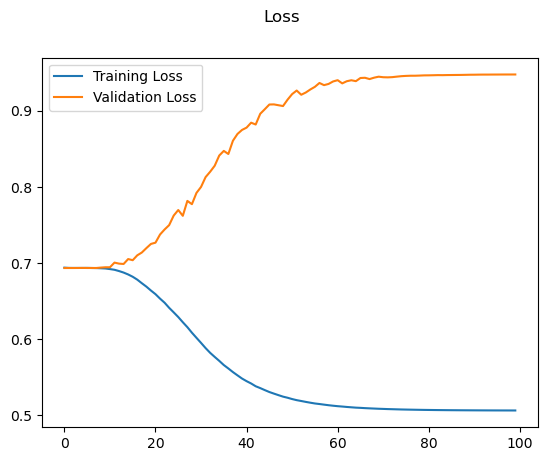

In [177]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plt.plot(training_record.history["loss"], label="Training Loss")
plt.plot(training_record.history["val_loss"], label="Validation Loss")
plt.legend()
fig.suptitle("Loss")
plt.show()

In [178]:
model.save('DACON0705.keras')